<a href="https://colab.research.google.com/github/Alancin321/Introducci-n-a-SI/blob/main/ExamenPractico2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.sans-serif': 'Arial', 'font.family': 'sans-serif'})

# Carga de datos
df = pd.read_csv('/content/real_estate_ecuador_200k.csv')
print(f"Total de registros cargados: {len(df):,}")

Total de registros cargados: 200,000


In [155]:
# 1, Limpieza de propiedades
# perimero con la columna de titulo
def clasificar_propiedad(titulo):
    t = str(titulo).lower()
    if any(k in t for k in ['suite', 'suit']): return 'Suite'
    elif any(k in t for k in ['departamento', 'dpto', 'dep', 'duplex', 'dúplex', 'loft', 'penthouse']): return 'Departamento'
    elif 'casa' in t: return 'Casa'
    elif any(k in t for k in ['local', 'comercial', 'oficina', 'consultorio', 'negocio', 'almacen', 'almacén']): return 'Local Comercial'
    elif any(k in t for k in ['bodega', 'galpon', 'galpón', 'nave industrial', 'edificio', 'hostel']): return 'Industrial / Comercial'
    elif any(k in t for k in ['terreno', 'lote']): return 'Terreno'
    else: return 'Otro'

df['Tipo_Propiedad'] = df['Titulo'].apply(clasificar_propiedad)

# 2. limpieza de ciudades
#segundo con la columna de lugares
def limpiar_ciudad(lugar):
    l = str(lugar).lower()
    if any(x in l for x in ['quito', 'cumbayá', 'cumbaya', 'tumbaco', 'pomasqui', 'calderon', 'conocoto', 'nayón', 'puembo', 'pifo', 'sangolquí', 'sangolqui', 'san rafael', 'rumiñahui']):
        if any(x in l for x in ['sangolqui', 'sangolquí', 'san rafael', 'rumiñahui']): return 'Sangolquí / Rumiñahui'
        else: return 'Quito (DM)'
    elif any(x in l for x in ['guayaquil', 'ceibos', 'urdesa', 'samborondón', 'samborondon', 'daule', 'durán', 'vía a la costa']):
        if 'samborondón' in l or 'samborondon' in l: return 'Samborondón'
        elif 'durán' in l: return 'Durán'
        elif 'daule' in l: return 'Daule'
        else: return 'Guayaquil'
    elif any(x in l for x in ['manta', 'portoviejo', 'manabí']): return 'Manta / Manabí'
    elif any(x in l for x in ['babahoyo', 'quevedo', 'los rios']): return 'Babahoyo / Los Ríos'
    elif any(x in l for x in ['esmeraldas', 'atacames', 'tonsupa']): return 'Esmeraldas'
    elif any(x in l for x in ['latacunga', 'cotopaxi']): return 'Latacunga'
    elif any(x in l for x in ['machala', 'el oro']): return 'Machala'
    elif any(x in l for x in ['ibarra', 'otavalo', 'imbabura']): return 'Ibarra'
    elif any(x in l for x in ['salinas', 'santa elena']): return 'Salinas / Santa Elena'
    else:
        partes = str(lugar).split(',')
        return partes[-2].strip() if len(partes) >= 2 else str(lugar)
df['Ciudad'] = df['Lugar'].apply(limpiar_ciudad)


In [156]:
# Perspectiva Financiera.

# i. Precio Promedio General
precio_promedio_general = df['Precio'].mean()
print(f"               PERSPECTIVA FINANCIERA    \n")
print(f"i. Precio Promedio de Alquiler General: ${precio_promedio_general:,.2f} USD")

# ii. Costo Promedio por Metro Cuadrado (m^2)
# Nota metodológica: Calculamos el promedio de la relación Precio/Área para cada inmueble
costo_m2_promedio = (df['Precio'] / df['Area']).mean()
costo_m2_agregado = df['Precio'].sum() / df['Area'].sum()
print(f"ii. Costo Promedio por m^2 (Promedio de razones): ${costo_m2_promedio:,.2f} USD/m^2")

# iii. Rango de Precios (Min/Max/Media) por Provincia
rango_provincias = df.groupby('Provincia')['Precio'].agg(
    Mínimo='min', Máximo='max', Media='mean', Conteo='count'
).reset_index().sort_values('Media', ascending=False)

print("\n          iii. Rango de Precios por Provincia    ")
display(rango_provincias)

               PERSPECTIVA FINANCIERA    

i. Precio Promedio de Alquiler General: $732.35 USD
ii. Costo Promedio por m^2 (Promedio de razones): $5.89 USD/m^2

          iii. Rango de Precios por Provincia    


,Provincia,Mínimo,Máximo,Media,Conteo
6,Manabí,5176.48,7920.44,6503.102091,416
0,Cotopaxi,94.47,4557.66,1814.528859,859
8,Pichincha,80.21,11062.33,734.507750,180673
3,Guayas,130.85,2816.34,614.669888,13960
4,Imbabura,380.54,589.42,480.809447,398
2,Esmeraldas,111.33,620.53,327.772537,804
5,Los Rios,176.04,295.08,233.589620,1288
7,Orellana,118.86,185.84,149.863608,413
1,El Oro,98.42,155.03,124.352068,793
9,Santa Elena,7.22,11.03,8.968586,396


In [157]:
print("--- PERSPECTIVA DE PRODUCTO ---")

# i. Distribución por Tipo de Propiedad
print("\ni. Conteo por Tipo de Propiedad:")
tabla_tipos = (
    df["Tipo_Propiedad"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "Tipo", "Tipo_Propiedad": "Conteo"})
)
display(tabla_tipos)

# ii. Tamaño Promedio por Provincia (Area_m2) - Redondeado a 2 decimales
tamanio_provincia = (
    df.groupby("Provincia")["Area"]
    .mean()
    .reset_index()
    .sort_values("Area", ascending=False)
)
tamanio_provincia.columns = ["Provincia", "Área Promedio (m²)"]
tamanio_provincia["Área Promedio (m²)"] = tamanio_provincia["Área Promedio (m²)"].round(
    2
)
print("\nii. Tamaño Promedio de Propiedades por Provincia:")
display(tamanio_provincia)

# iii. Premium por Habitación Adicional (Sin NaN y redondeado)
dorm_df = (
    df[df["Num. dormitorios"].isin([1, 2, 3, 4, 5])]
    .groupby("Num. dormitorios")["Precio"]
    .mean()
    .reset_index()
)
dorm_df["Diferencia_Premium"] = dorm_df["Precio"].diff()
dorm_df["Transición"] = [
    "1 Hab (Base)",
    "De 1 a 2 Habs",
    "De 2 a 3 Habs",
    "De 3 a 4 Habs",
    "De 4 a 5 Habs",
]

tabla_premium = dorm_df.iloc[1:][["Transición", "Precio", "Diferencia_Premium"]].copy()
tabla_premium["Precio"] = tabla_premium["Precio"].round(2)
tabla_premium["Diferencia_Premium"] = tabla_premium["Diferencia_Premium"].round(2)
tabla_premium.columns = [
    "Transición",
    "Precio Promedio ($)",
    "Premium Adicional ($)",
]

print("\niii. Premium de Precio por Habitación Adicional:")
display(tabla_premium)

--- PERSPECTIVA DE PRODUCTO ---

i. Conteo por Tipo de Propiedad:


,Conteo,count
0,Departamento,91098
1,Local Comercial,49418
2,Suite,25868
3,Casa,19347
4,Industrial / Comercial,6779
5,Otro,6268
6,Terreno,1222



ii. Tamaño Promedio de Propiedades por Provincia:


,Provincia,Área Promedio (m²)
9,Santa Elena,199727.40
1,El Oro,5947.77
6,Manabí,199.65
8,Pichincha,166.80
4,Imbabura,140.62
2,Esmeraldas,110.38
3,Guayas,103.34
5,Los Rios,88.95
0,Cotopaxi,72.43
7,Orellana,27.99



iii. Premium de Precio por Habitación Adicional:


,Transición,Precio Promedio ($),Premium Adicional ($)
1,De 1 a 2 Habs,496.74,-87.15
2,De 2 a 3 Habs,591.99,95.25
3,De 3 a 4 Habs,1073.33,481.33
4,De 4 a 5 Habs,1307.77,234.45


In [158]:
print("                               PERSPECTIVA GEOGRÁFICA  ")

# i. Top 5 Sectores/Ubicaciones Más Caros (filtrando ubicaciones con al menos 50 registros para significancia estadística)
top_5_lugares = df.groupby('Lugar')['Precio'].agg(['count', 'mean']).reset_index()
top_5_lugares = top_5_lugares[top_5_lugares['count'] >= 50].sort_values('mean', ascending=False).head(5)
top_5_lugares.columns = ['Ubicación Exacta (Lugar)', 'Cantidad Inmuebles', 'Precio Promedio ($ USD)']

print("\ni. Top 5 Sectores/Ubicaciones Más Caras:")
display(top_5_lugares)

# ii. Concentración de la Oferta por Provincia
concentracion = df['Provincia'].value_counts(normalize=True).mul(100).round(2).reset_index()
concentracion.columns = ['Provincia', 'Participación de Oferta (%)']
print("\nii. Concentración de la Oferta Inmobiliaria:")
display(concentracion)

                               PERSPECTIVA GEOGRÁFICA  

i. Top 5 Sectores/Ubicaciones Más Caras:


,Ubicación Exacta (Lugar),Cantidad Inmuebles,Precio Promedio ($ USD)
99,"Pichincha, Avenida 10 de Agosto, Quito, Ecuador",408,9023.844069
38,"Manabí, Manta, Ecuador",416,6503.102091
215,"Pichincha, La Delicia, Quito, Ecuador",447,4999.131409
189,"Pichincha, Guamaní, Quito, Ecuador",411,3887.606034
0,"Cotopaxi, Latacunga, Cotopaxi, Ecuador",407,3697.685799



ii. Concentración de la Oferta Inmobiliaria:


,Provincia,Participación de Oferta (%)
0,Pichincha,90.34
1,Guayas,6.98
2,Los Rios,0.64
3,Cotopaxi,0.43
4,Esmeraldas,0.40
5,El Oro,0.40
6,Manabí,0.21
7,Orellana,0.21
8,Imbabura,0.20
9,Santa Elena,0.20


In [159]:
# Cálculo de Cuartiles
q1 = df['Precio'].quantile(0.25)
q3 = df['Precio'].quantile(0.75)

print(f"        SEGMENTACIÓN DE MERCADO \n")
print(f"- Cuartil 1 (Q1 - Límite Económico): ${q1:.2f} USD")
print(f"- Cuartil 3 (Q3 - Límite Lujo): ${q3:.2f} USD")

# Creación de la nueva columna
def segmentar_mercado(precio):
    if precio < q1: return 'Económico'
    elif precio > q3: return 'Lujo'
    else: return 'Medio'

df['Tipo_Inmueble'] = df['Precio'].apply(segmentar_mercado)

print("\nDistribución de la Segmentación de Mercado:")
display(df['Tipo_Inmueble'].value_counts().reset_index().rename(columns={'index':'Segmento', 'Tipo_Inmueble':'Conteo'}))

        SEGMENTACIÓN DE MERCADO 

- Cuartil 1 (Q1 - Límite Económico): $371.77 USD
- Cuartil 3 (Q3 - Límite Lujo): $728.64 USD

Distribución de la Segmentación de Mercado:


,Conteo,count
0,Medio,100001
1,Lujo,50000
2,Económico,49999


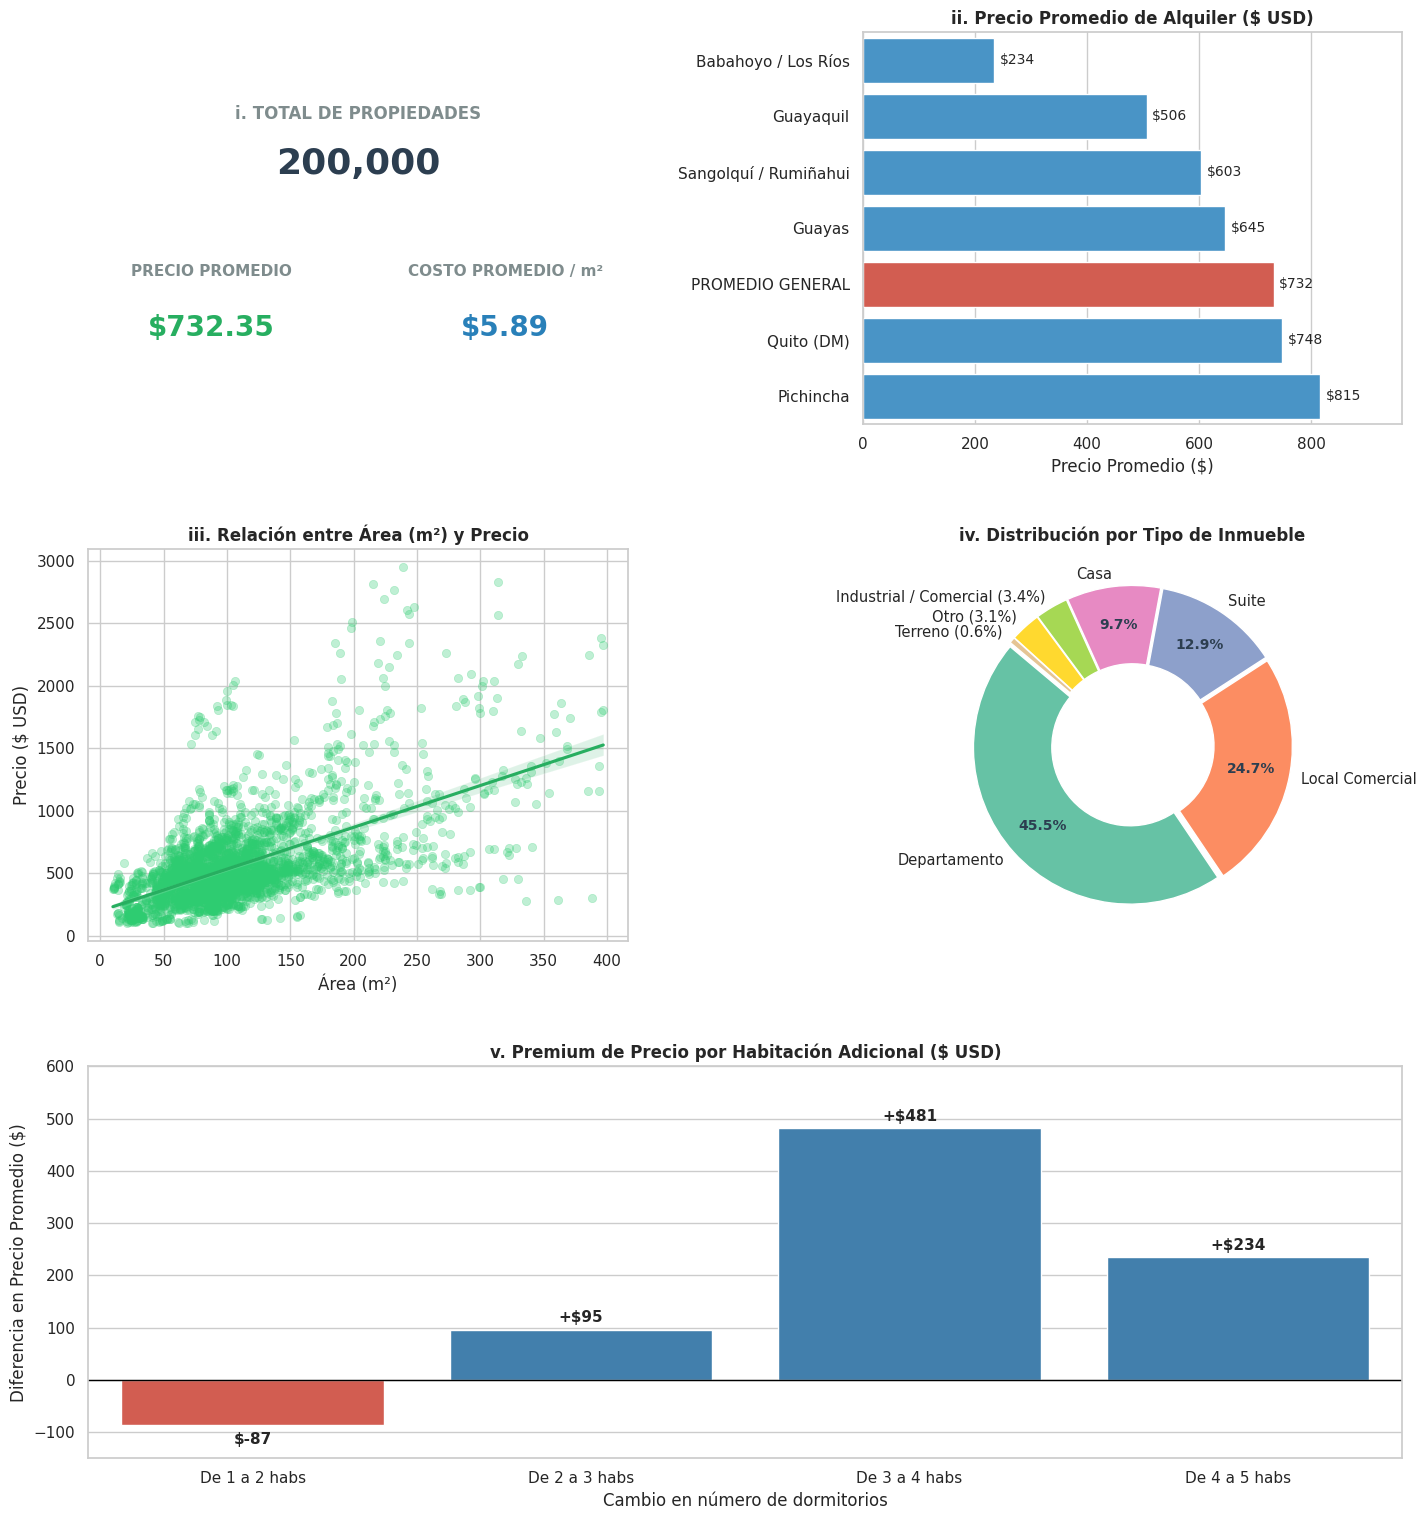

In [160]:

# Kpis
total_props = len(df)
precio_prom = df['Precio'].mean()
costo_m2 = (df['Precio'] / df['Area']).mean()

# 3. Generación del Dashboard
fig = plt.figure(figsize=(15, 16))

# i. Total de propiedades
ax1 = plt.subplot(3, 2, 1)
ax1.plot([0, 1], [0, 1], alpha=0)
ax1.axis('off')

ax1.text(0.5, 0.82, 'i. TOTAL DE PROPIEDADES', ha='center', va='center', fontsize=12, color='#7f8c8d', fontweight='bold')
ax1.text(0.5, 0.68, f"{total_props:,}", ha='center', va='center', fontsize=26, color='#2c3e50', fontweight='bold')

ax1.text(0.20, 0.38, 'PRECIO PROMEDIO', ha='center', va='center', fontsize=11, color='#7f8c8d', fontweight='bold')
ax1.text(0.20, 0.22, f"${precio_prom:,.2f}", ha='center', va='center', fontsize=20, color='#27ae60', fontweight='bold')

ax1.text(0.80, 0.38, 'COSTO PROMEDIO / m²', ha='center', va='center', fontsize=11, color='#7f8c8d', fontweight='bold')
ax1.text(0.80, 0.22, f"${costo_m2:,.2f}", ha='center', va='center', fontsize=20, color='#2980b9', fontweight='bold')

# ii. Gráfico de barras de Precio promedio de alquiler
ax2 = plt.subplot(3, 2, 2)
ciudades = df['Ciudad'].value_counts().head(6).index
df_c = df[df['Ciudad'].isin(ciudades)].groupby('Ciudad')['Precio'].mean().reset_index()
df_gen = pd.DataFrame([{'Ciudad': 'PROMEDIO GENERAL', 'Precio': precio_prom}])
df_plot2 = pd.concat([df_gen, df_c], ignore_index=True).sort_values('Precio')

colores_b = ['#e74c3c' if x == 'PROMEDIO GENERAL' else '#3498db' for x in df_plot2['Ciudad']]
sns.barplot(data=df_plot2, x='Precio', y='Ciudad', hue='Ciudad', palette=colores_b, ax=ax2, dodge=False)
if ax2.get_legend() is not None: ax2.get_legend().remove()
ax2.set_title('ii. Precio Promedio de Alquiler ($ USD)', fontweight='bold', fontsize=12)
ax2.set_xlabel('Precio Promedio ($)')
ax2.set_ylabel('')
for p in ax2.patches:
    ax2.text(p.get_width() + 10, p.get_y() + p.get_height()/2., f"${p.get_width():,.0f}", va='center', fontsize=10)
ax2.set_xlim(0, df_plot2['Precio'].max() * 1.18)

# iii. RELACIÓN ENTRE ÁREA Y PRECIO
ax3 = plt.subplot(3, 2, 3)
muestra = df[(df['Area'] < 400) & (df['Precio'] < 3000)].sample(3000, random_state=42)
sns.scatterplot(data=muestra, x='Area', y='Precio', alpha=0.3, color='#2ecc71', edgecolor=None, ax=ax3)
sns.regplot(data=muestra, x='Area', y='Precio', scatter=False, color='#27ae60', ax=ax3)
ax3.set_title('iii. Relación entre Área (m²) y Precio', fontweight='bold', fontsize=12)
ax3.set_xlabel('Área (m²)')
ax3.set_ylabel('Precio ($ USD)')

# iv. DISTRIBUCIÓN POR TIPO DE INMUEBLE (Etiquetado Híbrido Inteligente)
ax4 = plt.subplot(3, 2, 4)
conteo_tipos = df['Tipo_Propiedad'].value_counts()
colores_paleta = sns.color_palette("Set2", len(conteo_tipos))
separacion = [0.02] * len(conteo_tipos)

etiquetas_limpias = [
    f"{idx} ({val/len(df)*100:.1f}%)" if (val/len(df)*100) < 4 else idx
    for idx, val in conteo_tipos.items()
]

def autopct_limpio(pct):
    return f"{pct:.1f}%" if pct >= 4.0 else ""

wedges, texts, autotexts = ax4.pie(conteo_tipos, labels=etiquetas_limpias, autopct=autopct_limpio, startangle=140, colors=colores_paleta, pctdistance=0.75,
labeldistance=1.08,
    explode=separacion,
    wedgeprops=dict(width=0.5, edgecolor='w')
)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('#2c3e50')

for text in texts:
    text.set_fontsize(10.5)

ax4.set_title('iv. Distribución por Tipo de Inmueble', fontweight='bold', fontsize=12)

# v. PREMIUM POR HABITACIÓN ADICIONAL
ax5 = plt.subplot(3, 1, 3)
dorm_df = df[df['Num. dormitorios'].isin([1, 2, 3, 4, 5])].groupby('Num. dormitorios')['Precio'].mean().reset_index()
dorm_df['Premium'] = dorm_df['Precio'].diff()
dorm_plot = dorm_df.iloc[1:].copy()
dorm_plot['Transicion'] = ['De 1 a 2 habs', 'De 2 a 3 habs', 'De 3 a 4 habs', 'De 4 a 5 habs']

colores_d = ['#e74c3c' if x < 0 else '#3182bd' for x in dorm_plot['Premium']]
sns.barplot(data=dorm_plot, x='Transicion', y='Premium', hue='Transicion', palette=colores_d, ax=ax5, dodge=False)
if ax5.get_legend() is not None: ax5.get_legend().remove()
ax5.set_title('v. Premium de Precio por Habitación Adicional ($ USD)', fontweight='bold', fontsize=12)
ax5.set_xlabel('Cambio en número de dormitorios')
ax5.set_ylabel('Diferencia en Precio Promedio ($)')
ax5.axhline(0, color='black', linewidth=1)

for p in ax5.patches:
    val = p.get_height()
    pos_y = val + 15 if val >= 0 else val - 35
    signo = "+" if val >= 0 else ""
    ax5.text(p.get_x() + p.get_width()/2., pos_y, f"{signo}${val:,.0f}", ha='center', fontweight='bold', fontsize=11)

ax5.set_ylim(-150, 600)

plt.tight_layout(pad=3.0)
plt.savefig('dashboard_impecable.png', dpi=300)
plt.show()